Install ucirepo with pip install command

In [118]:
!pip install ucimlrepo

Import the data and tools

In [119]:
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.
Load the CKD dataset into a single data frame and read its description.

In [120]:
# fetch dataset as a pandas DataFrame
chronic_kidney_disease :pd.DataFrame = fetch_ucirepo(id=336)


# data as pandas dataframes
measurement_data :pd.DataFrame = chronic_kidney_disease.data.features
diagnosis_data :pd.DataFrame = chronic_kidney_disease.data.targets

# metadata
metadata :pd.Series = chronic_kidney_disease.metadata


# Combine measurements and diagnosis into a single data frame
raw = pd.concat([measurement_data, diagnosis_data], axis=1)

print(f"Original shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
display(raw.head())
display(
    pd.DataFrame(
        {
            "dtype": raw.dtypes.astype(str),
            "missing": raw.isna().sum(),
            "missing_%": raw.isna().mean().mul(100).round(1),
            "unique_non_missing": raw.nunique(dropna=True),
        }
    )
)

Original shape: 400 rows x 25 columns


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


,dtype,missing,missing_%,unique_non_missing
age,float64,9,2.2,76
bp,float64,12,3.0,10
sg,float64,47,11.8,5
al,float64,46,11.5,6
su,float64,49,12.2,6
rbc,str,152,38.0,2
pc,str,65,16.2,2
pcc,str,4,1.0,2
ba,str,4,1.0,2
bgr,float64,44,11.0,146


In [121]:
# metadata has descriptive information
print("\nMetadata:\n", metadata)


Metadata:
 {'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r

In [122]:
# variable information
print("\nVariables:\n", chronic_kidney_disease.variables)


Variables:
      name     role         type demographic              description  \
0     age  Feature      Integer         Age                      NaN   
1      bp  Feature      Integer         NaN           blood pressure   
2      sg  Feature  Categorical         NaN         specific gravity   
3      al  Feature  Categorical         NaN                  albumin   
4      su  Feature  Categorical         NaN                    sugar   
5     rbc  Feature       Binary         NaN          red blood cells   
6      pc  Feature       Binary         NaN                 pus cell   
7     pcc  Feature       Binary         NaN          pus cell clumps   
8      ba  Feature       Binary         NaN                 bacteria   
9     bgr  Feature      Integer         NaN     blood glucose random   
10     bu  Feature      Integer         NaN               blood urea   
11     sc  Feature   Continuous         NaN         serum creatinine   
12    sod  Feature      Integer         NaN        

In [123]:
# pandas has .describe() method
print("\nvariables.describe:\n",chronic_kidney_disease.variables.describe())


variables.describe:
        name     role    type demographic     description   units  \
count    25       25      25           1              24      10   
unique   25        2       4           1              24       7   
top     age  Feature  Binary         Age  blood pressure  mgs/dl   
freq      1       24      11           1               1       3   

       missing_values  
count              25  
unique              2  
top               yes  
freq               24  


In [124]:
# data_features has data table
measurement_data.head(5)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


In [125]:
# diagnosis_data has has diagnosis whether subject has chronic kidney disease (cdk) or no (nockd)
diagnosis_data

,class
0,ckd
1,ckd
2,ckd
3,ckd
4,ckd
...,...
395,notckd
396,notckd
397,notckd
398,notckd


2.
Construct a pipeline for modifying the data frame.

The modified data frame should meet the following requirements:

- It should include exactly the following columns:
  - age
  - blood pressure
  - specific gravity
  - albumin
  - sugar
  - blood glucose random
  - blood urea
  - sodium
  - potassium
  - hemoglobin
  - packed cell volume
  - white blood cell count
  - red blood cell count
  - class


In [126]:
# list of wanted columns
wanted_columns = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'class']

# abbreviations of columns
columns_dictionary = {
"age" : "age",
"bp" : "blood pressure",
"sg" : "specific gravity",
"al" : "albumin",
"su" : "sugar",
"rbc" : "red blood cells",
"pc" : "pus cell",
"pcc" : "pus cell clumps",
"ba" : "bacteria",
"bgr" : "blood glucose random",
"bu" : "blood urea",
"sc" : "serum creatinine",
"sod" : "sodium",
"pot" : "potassium",
"hemo" : "hemoglobin",
"pcv" : "packed cell volume",
"wbcc" : "white blood cell count",
"rbcc" : "red blood cell count",
"htn" : "hypertension",
"dm" : "diabetes mellitus",
"cad" : "coronary artery disease",
"appet" : "appetite",
"pe" : "pedal edema",
"ane" : "anemia",
"class" : "class"
}

# class column is in different table and has to be joined, make a new copy
modified_data_frame :pd.DataFrame = measurement_data.join(diagnosis_data, how="left").copy(deep=True)
modified_data_frame.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='str')

In [127]:
# filter wanted columns
modified_data_frame :pd.DataFrame  = modified_data_frame.filter(items=wanted_columns, axis="columns")
modified_data_frame.head(5)

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6,ckd


In [128]:
modified_data_frame["hemo"].unique().sort()

- The hemoglobin values should be expressed in g/l. In the original data set, they are expressed as g/dl.





In [129]:
# conversion ratio from g/dl -> g/l is 10
modified_data_frame["hemo"] = modified_data_frame["hemo"] * 10

#
modified_data_frame.head(5)

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,ckd


In [130]:
# filter variables from original data frame to modified one by the name of the column
modified_data_frame.variables =  chronic_kidney_disease.variables[chronic_kidney_disease.variables["name"].isin(wanted_columns)] #TODO: tarvitseeko modifed_data_frame variables attribuuttia ollenkaan? voisi vain tehdä erillisen modified_variables taulun?

# test print
modified_data_frame.variables

C:\Users\taifj\AppData\Local\Temp\ipykernel_27992\1672080039.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  modified_data_frame.variables =  chronic_kidney_disease.variables[chronic_kidney_disease.variables["name"].isin(wanted_columns)] #TODO: tarvitseeko modifed_data_frame variables attribuuttia ollenkaan? voisi vain tehdä erillisen modified_variables taulun?


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,NaN,year,yes
1,bp,Feature,Integer,NaN,blood pressure,mm/Hg,yes
2,sg,Feature,Categorical,NaN,specific gravity,NaN,yes
3,al,Feature,Categorical,NaN,albumin,NaN,yes
4,su,Feature,Categorical,NaN,sugar,NaN,yes
9,bgr,Feature,Integer,NaN,blood glucose random,mgs/dl,yes
10,bu,Feature,Integer,NaN,blood urea,mgs/dl,yes
12,sod,Feature,Integer,NaN,sodium,mEq/L,yes
13,pot,Feature,Continuous,NaN,potassium,mEq/L,yes
14,hemo,Feature,Continuous,NaN,hemoglobin,gms,yes


In [131]:
# change the unit of hemoglobin to g/l
modified_data_frame.variables.replace("gms", "g/l", inplace=True)

#test print
modified_data_frame.variables.iloc[9]

name                    hemo
role                 Feature
type              Continuous
demographic              NaN
description       hemoglobin
units                    g/l
missing_values           yes
Name: 14, dtype: str

- The values of the class column should be recoded as a or c (affected or control).

In [132]:
# see what is in class column
modified_data_frame["class"].unique()

<ArrowStringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str

In [133]:
# replace the values in class column with "a" or "c"
modified_data_frame["class"] = modified_data_frame["class"].replace({"ckd" : "a", "ckd\t" : "a", "notckd" : "c"})

# only "a" and "c" should remain
modified_data_frame["class"].unique()

# test print
modified_data_frame#.head(5)


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


- Rows with three or more missing values should be removed. Indicate the number of rows left in the modified data frame.

In [134]:
# filter missing values with pandas.dropna()
modified_data_frame.dropna(thresh=3, inplace=True)

# test print
modified_data_frame#.head(5)

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


We remove rows that contain three or more missing values.

In [135]:
# Count missing values in each row
missing_per_row = modified_data_frame.isna().sum(axis=1)
display(missing_per_row.to_frame("missing"))

# Remove rows with three or more missing values
modified_data_frame = modified_data_frame[missing_per_row < 3].copy()

# Verify the result
missing_after = modified_data_frame.isna().sum(axis=1)

print("Maximum number of missing values in a retained row:",
      missing_after.max())

print("Number of rows remaining:",
      len(modified_data_frame))

display(modified_data_frame)

,missing
0,2
1,4
2,3
3,0
4,2
...,...
395,0
396,0
397,0
398,0


Maximum number of missing values in a retained row: 2
Number of rows remaining: 265


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


Cleaning result


3.
Next, split the data frame into two data frames, one for the affected individuals and one for the control individuals. Display the data frames, and indicate the number of rows in each data frame.

a means affected (original class ckd) and c means control (original class notckd). Each displayed data frame includes the same 14 required columns.

In [136]:
affected = modified_data_frame.loc[modified_data_frame["class"].eq("a")].copy()
control = modified_data_frame.loc[modified_data_frame["class"].eq("c")].copy()

assert len(affected) + len(control) == len(modified_data_frame)

print(f"Affected individuals: {len(affected)} rows")
display(affected)

print(f"Control individuals: {len(control)} rows")
display(control)

Affected individuals: 126 rows


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.0,90.0,1.020,2.0,1.0,169.0,48.0,138.0,2.9,134.0,47.0,11000.0,6.1,a
244,64.0,90.0,1.015,3.0,2.0,463.0,64.0,135.0,4.1,122.0,40.0,9800.0,4.6,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.0,5.7,86.0,26.0,5000.0,2.5,a
248,59.0,70.0,1.010,1.0,3.0,424.0,55.0,138.0,4.5,126.0,37.0,10200.0,4.1,a


Control individuals: 139 rows


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
250,40.0,80.0,1.025,0.0,0.0,140.0,10.0,135.0,5.0,150.0,48.0,10400.0,4.5,c
251,23.0,80.0,1.025,0.0,0.0,70.0,36.0,150.0,4.6,170.0,52.0,9800.0,5.0,c
252,45.0,80.0,1.025,0.0,0.0,82.0,49.0,147.0,4.4,159.0,46.0,9100.0,4.7,c
253,57.0,80.0,1.025,0.0,0.0,119.0,17.0,135.0,4.7,154.0,42.0,6200.0,6.2,c
254,51.0,60.0,1.025,0.0,0.0,99.0,38.0,135.0,3.7,130.0,49.0,8300.0,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


In [137]:
# Select only numeric columns for correlation
numeric_df = modified_data_frame.select_dtypes(include=[np.number])
numeric_df.corr().round(2)

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
age,1.00,0.13,-0.28,0.22,0.21,0.29,0.18,-0.15,0.01,-0.24,-0.26,0.14,-0.26
bp,0.13,1.00,-0.24,0.26,0.28,0.19,0.21,-0.13,0.08,-0.31,-0.33,0.05,-0.23
sg,-0.28,-0.24,1.00,-0.56,-0.33,-0.42,-0.40,0.47,-0.03,0.65,0.63,-0.24,0.59
al,0.22,0.26,-0.56,1.00,0.35,0.40,0.60,-0.47,0.17,-0.68,-0.66,0.25,-0.58
su,0.21,0.28,-0.33,0.35,1.00,0.74,0.15,-0.20,0.17,-0.22,-0.25,0.20,-0.25
bgr,0.29,0.19,-0.42,0.40,0.74,1.00,0.22,-0.29,0.06,-0.33,-0.35,0.19,-0.31
bu,0.18,0.21,-0.40,0.60,0.15,0.22,1.00,-0.47,0.20,-0.65,-0.64,0.05,-0.59
sod,-0.15,-0.13,0.47,-0.47,-0.20,-0.29,-0.47,1.00,-0.03,0.53,0.53,-0.08,0.47
pot,0.01,0.08,-0.03,0.17,0.17,0.06,0.20,-0.03,1.00,-0.14,-0.17,-0.11,-0.16
hemo,-0.24,-0.31,0.65,-0.68,-0.22,-0.33,-0.65,0.53,-0.14,1.00,0.89,-0.24,0.79


*  1 --> Strong postive relationship
*  0 --> No relationship
* -1 --> Strong negative relationship

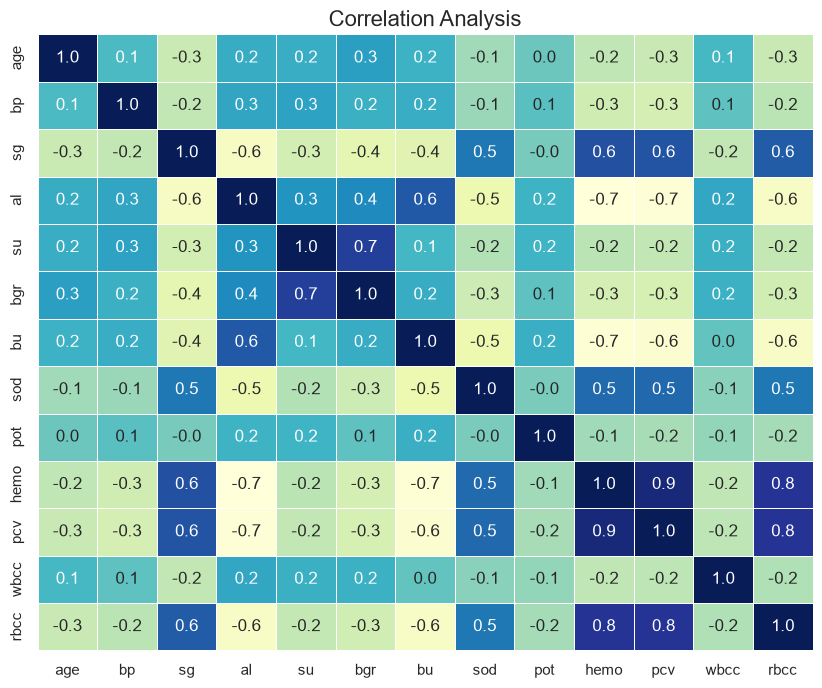

In [138]:
sns.set(font_scale=1,style="whitegrid" )
plt.figure(figsize=(10, 8))
plot = sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu", fmt=".1f", cbar=False, linewidths=0.5)
plot.set_title("Correlation Analysis", fontsize=16)
plt.show()

4. Basic Statistics and Clear Histograms
First for each data frame, calculate the basic statistics for each column.

In [139]:
# Select numerical columns for statistical analysis
numeric_columns = affected.select_dtypes(include=np.number).columns

# Basic statistics for affected individuals
print("Basic statistics for affected individuals:")
display(affected[numeric_columns].describe().round(2))

# Basic statistics for control individuals
print("Basic statistics for control individuals:")
display(control[numeric_columns].describe().round(2))

Basic statistics for affected individuals:


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
count,123.00,125.00,125.00,126.00,126.00,120.00,125.00,108.00,108.00,125.00,125.00,113.00,108.00
mean,57.08,80.72,1.01,1.85,0.81,181.20,80.42,133.73,4.75,106.43,32.44,9450.44,3.98
std,14.47,15.77,0.00,1.44,1.37,93.55,60.50,7.67,4.20,21.90,7.15,3720.46,0.84
min,6.00,50.00,1.00,0.00,0.00,22.00,1.50,104.00,2.50,31.00,9.00,2600.00,2.10
25%,49.50,70.00,1.01,0.25,0.00,107.00,37.00,131.75,3.80,95.00,29.00,7100.00,3.40
50%,60.00,80.00,1.01,2.00,0.00,158.00,60.00,136.00,4.20,108.00,33.00,9200.00,3.90
75%,65.00,90.00,1.01,3.00,1.00,241.25,107.00,139.00,4.90,120.00,37.00,11000.00,4.40
max,90.00,180.00,1.02,5.00,5.00,490.00,322.00,145.00,47.00,161.00,52.00,26400.00,8.00


Basic statistics for control individuals:


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
count,139.00,137.00,139.00,139.0,139.0,135.00,135.00,136.00,136.00,137.00,138.00,136.00,136.00
mean,46.57,71.31,1.02,0.0,0.0,107.39,32.87,141.74,4.34,151.88,46.25,7708.09,5.38
std,15.90,8.56,0.00,0.0,0.0,18.75,11.48,4.79,0.60,12.85,4.11,1815.16,0.59
min,12.00,60.00,1.02,0.0,0.0,70.00,10.00,135.00,3.30,130.00,40.00,4300.00,4.50
25%,34.00,60.00,1.02,0.0,0.0,93.00,23.50,138.00,3.70,141.00,43.00,6300.00,4.90
50%,46.00,70.00,1.02,0.0,0.0,107.00,33.00,141.00,4.50,150.00,46.00,7450.00,5.30
75%,58.00,80.00,1.02,0.0,0.0,123.50,44.00,146.00,4.90,162.00,50.00,9225.00,5.90
max,80.00,80.00,1.02,0.0,0.0,140.00,50.00,150.00,5.00,178.00,54.00,11000.00,6.50


- Histograms
then provide clear, readable histograms for each numerical column.

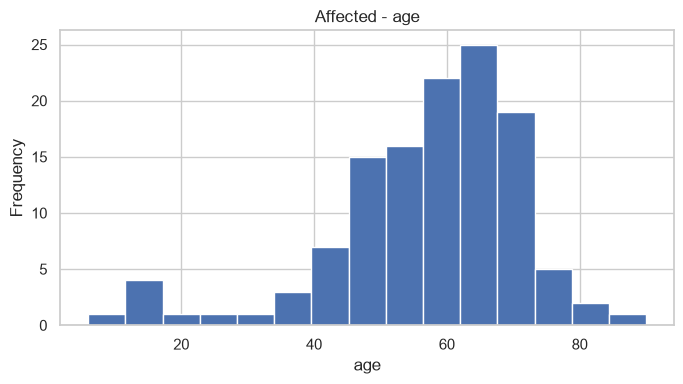

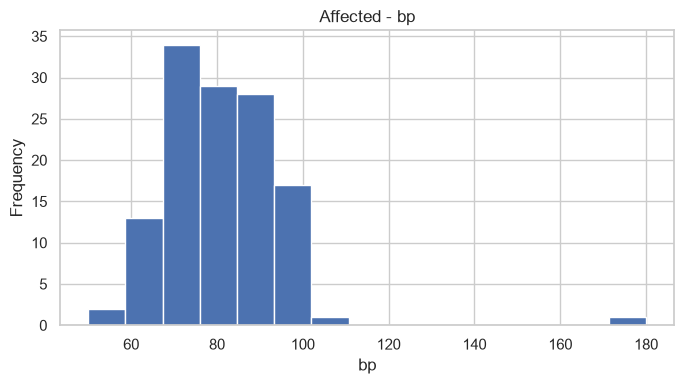

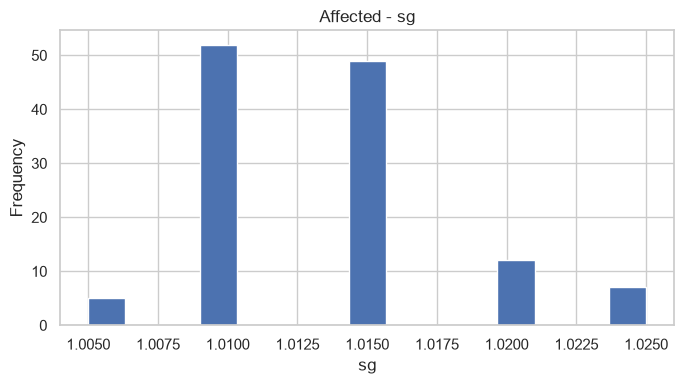

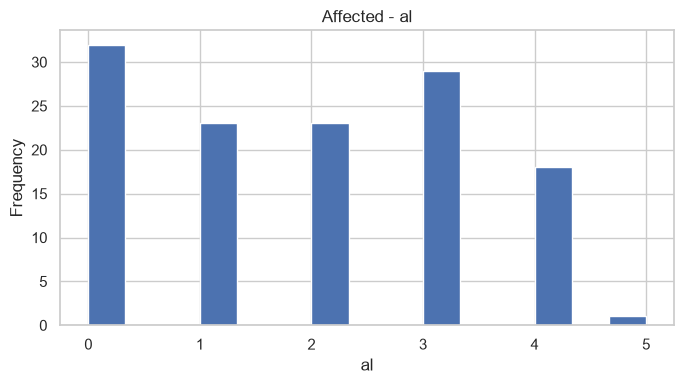

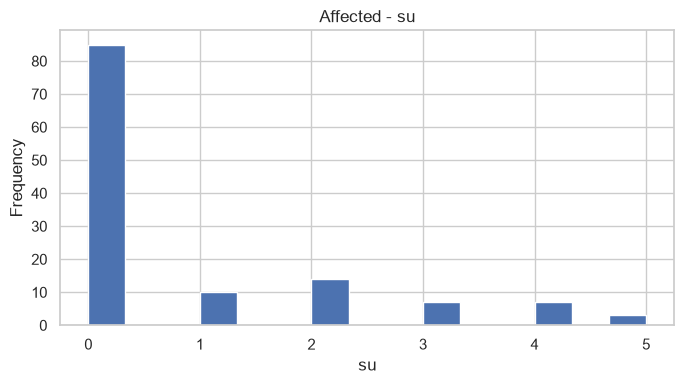

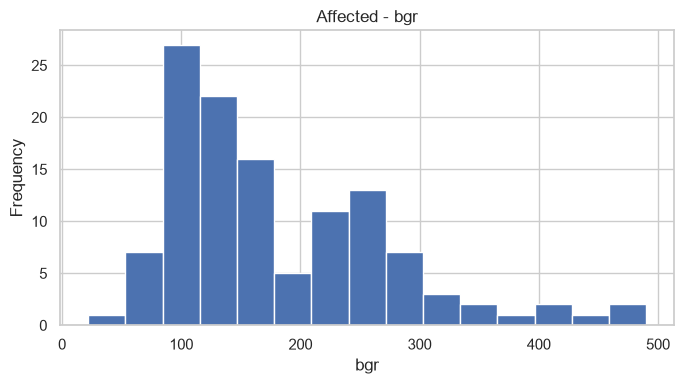

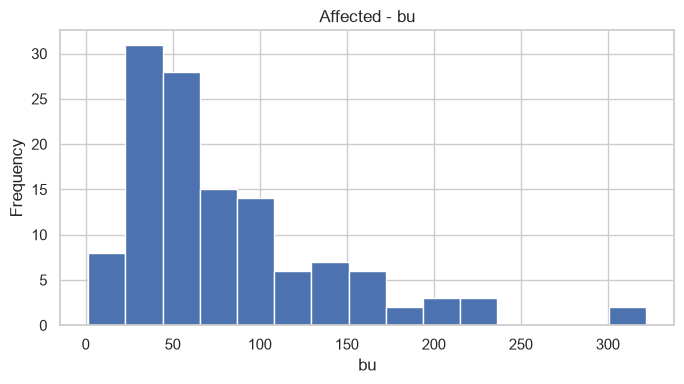

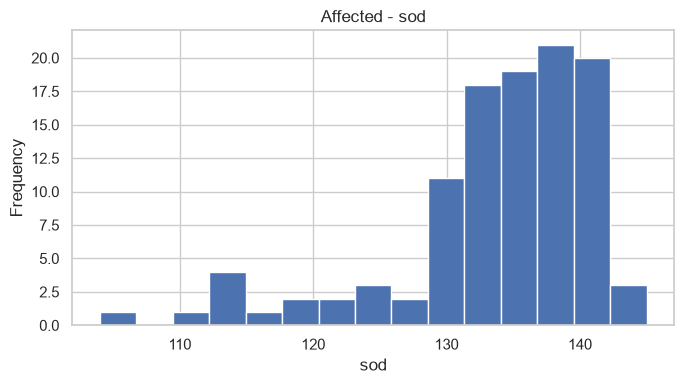

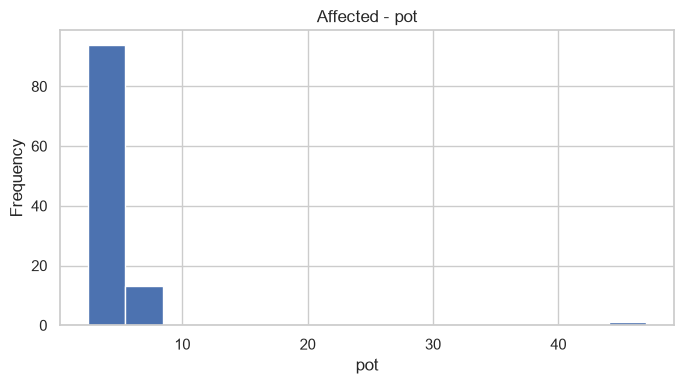

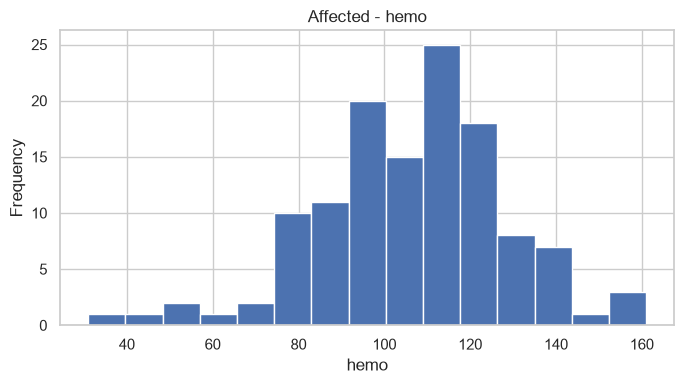

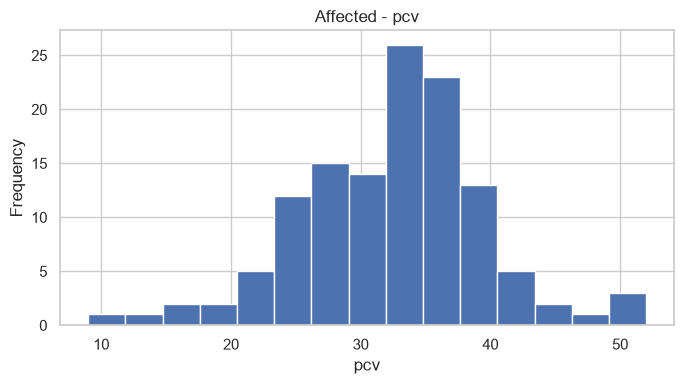

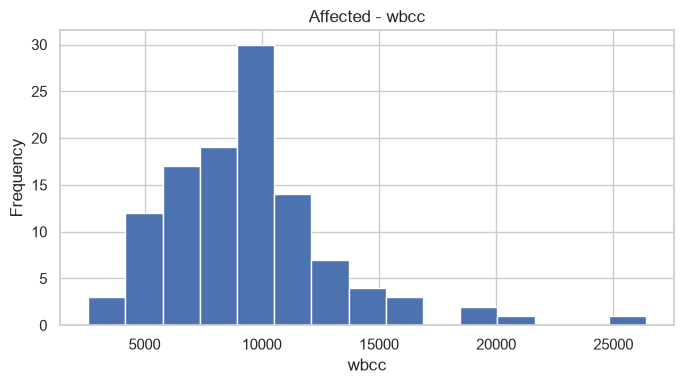

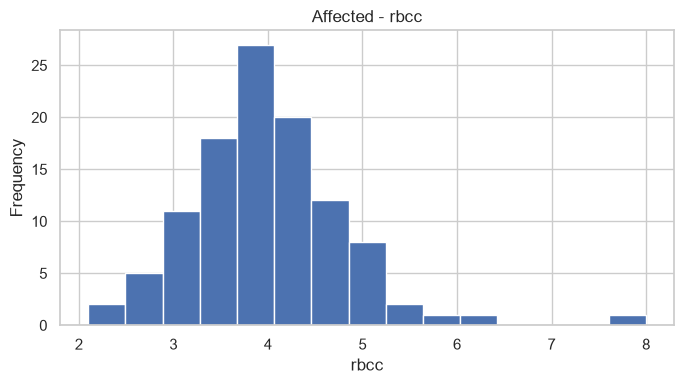

In [140]:
# Histograms for each numeric column in the affected dataset
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    affected[column].dropna().hist(bins=15)
    plt.title(f"Affected - {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

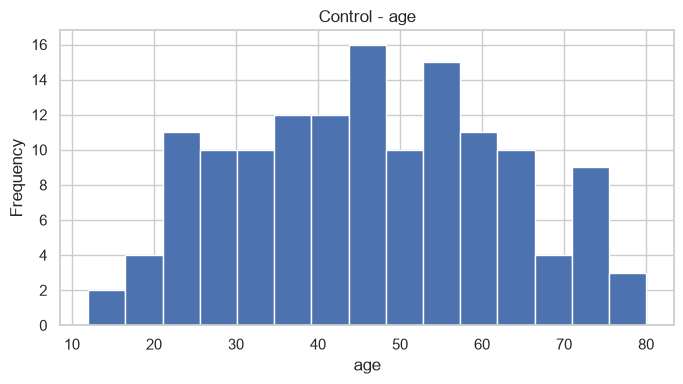

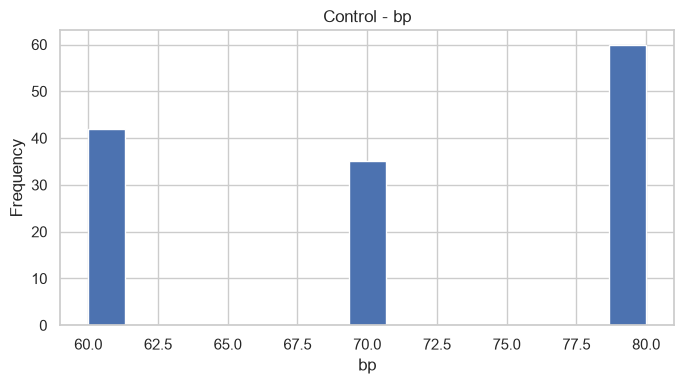

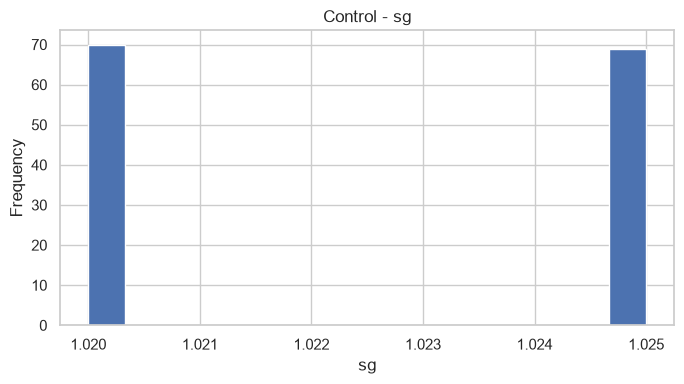

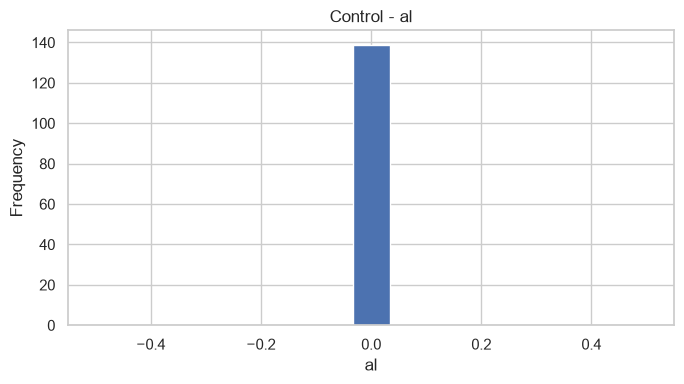

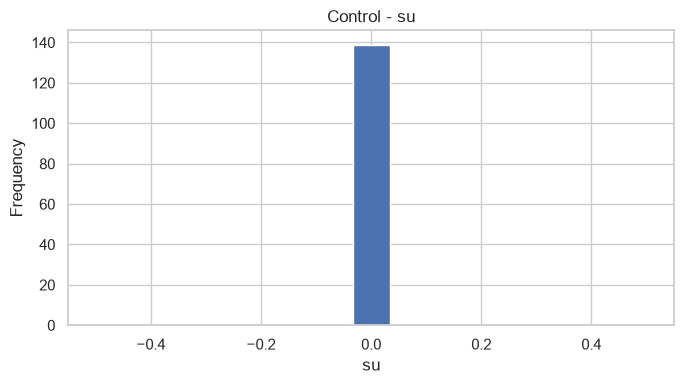

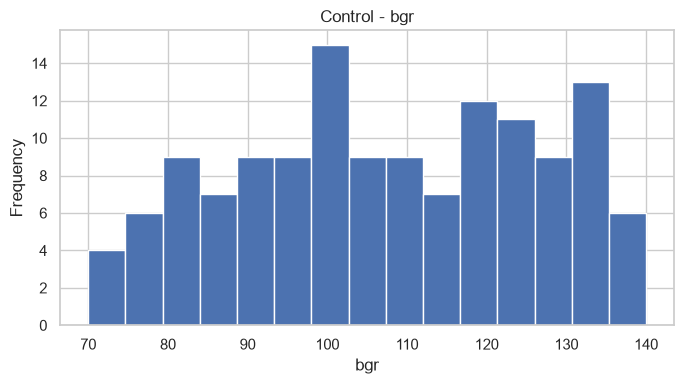

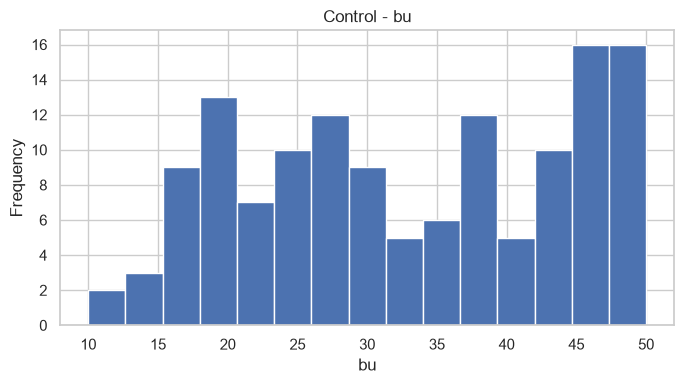

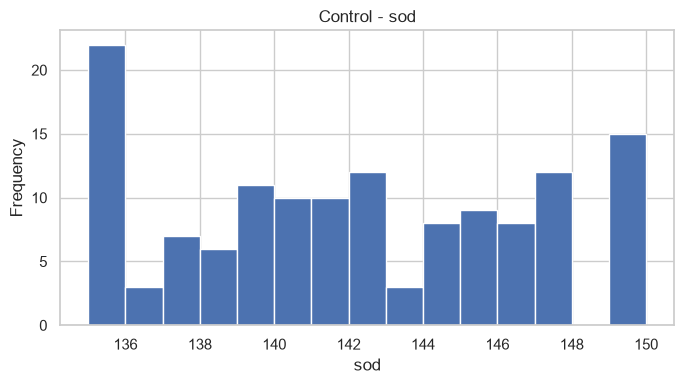

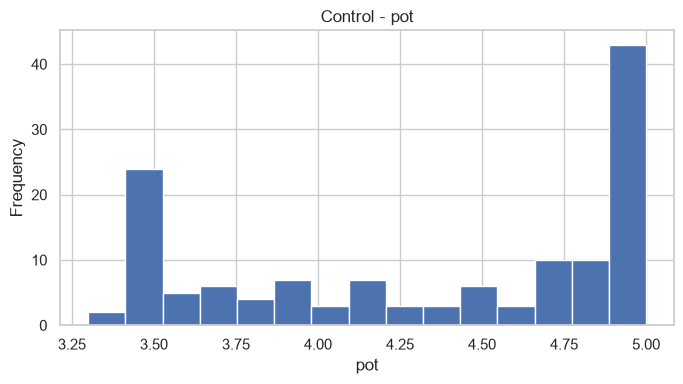

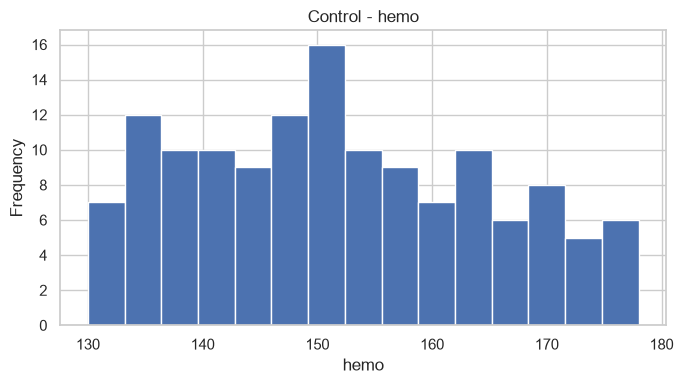

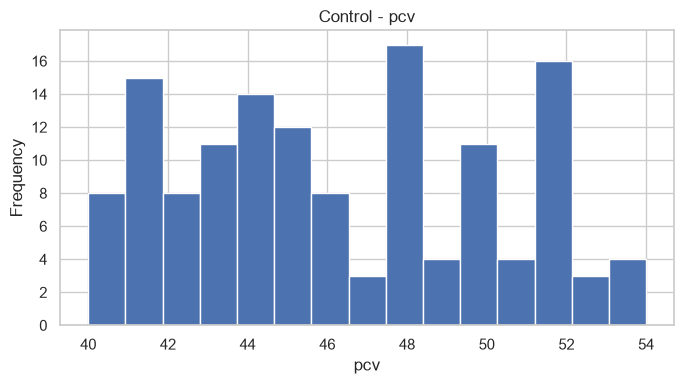

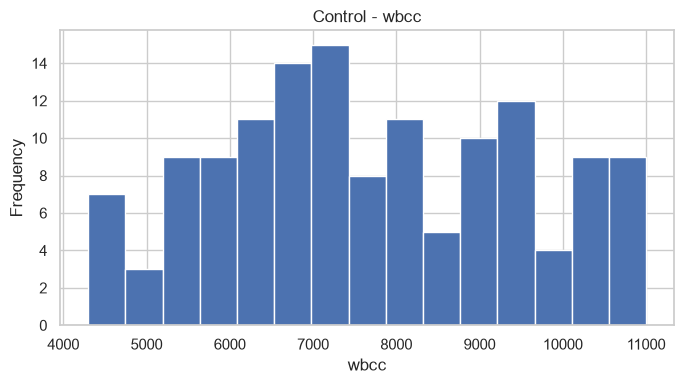

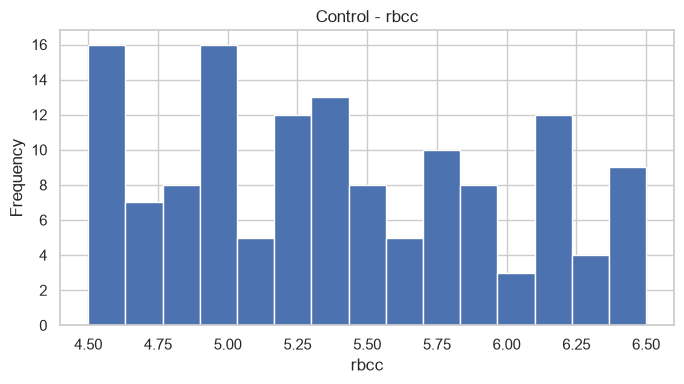

In [141]:
# Histograms for each numeric column in the control dataset
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    control[column].dropna().hist(bins=15)
    plt.title(f"Control - {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The histograms were examined to identify unusual distributions and potential outliers. Potential outliers were identified using the IQR rule. Outliers were not automatically removed, because an extreme value may represent a genuine medical measurement rather than an error. Values should be investigated based on their plausibility and data quality before deciding whether to remove, correct, or retain them.

5.
Finally, calculate the correlation matrix and visualize it for each data frame. Clearly describe the results and your interpretation for it.